In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("analysis_ready_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (180519, 42)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode,Delay_Gap,Delivery_Class
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class,2,Delayed
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class,0,On-time
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class,0,On-time
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class,2,Delayed
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class,2,Delayed


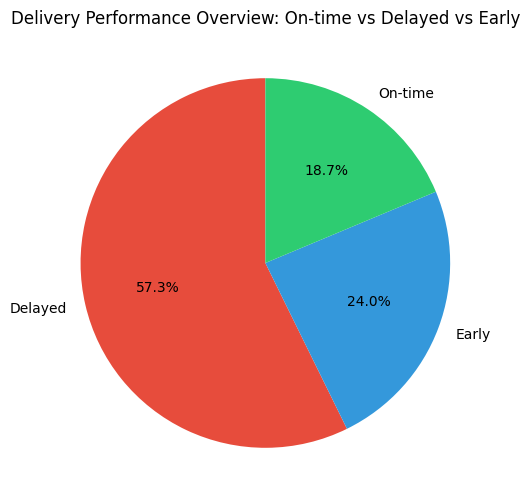

In [2]:
class_counts = df["Delivery_Class"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
        colors=['#e74c3c', '#3498db', '#2ecc71'], startangle=90)
plt.title("Delivery Performance Overview: On-time vs Delayed vs Early")
plt.show()

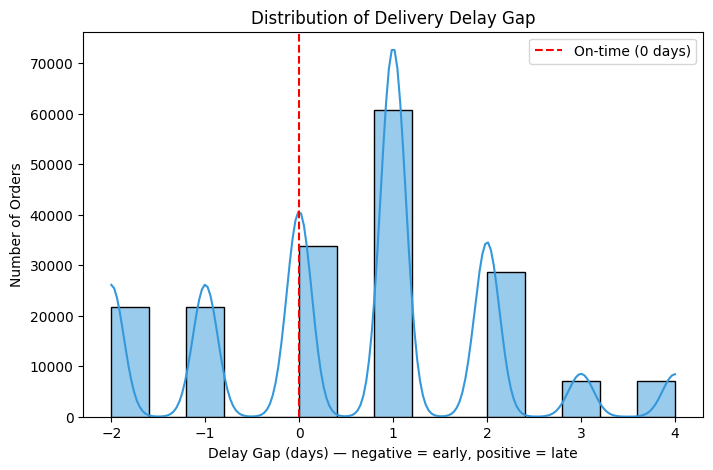

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df["Delay_Gap"], bins=15, kde=True, color='#3498db')
plt.axvline(0, color='red', linestyle='--', label='On-time (0 days)')
plt.title("Distribution of Delivery Delay Gap")
plt.xlabel("Delay Gap (days) — negative = early, positive = late")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()

/var/folders/79/lc0zk5fj6rjc0j34wk_c5gn00000gn/T/ipykernel_37341/1636679299.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Shipping Mode", y="Delay_Gap", palette="Set2")


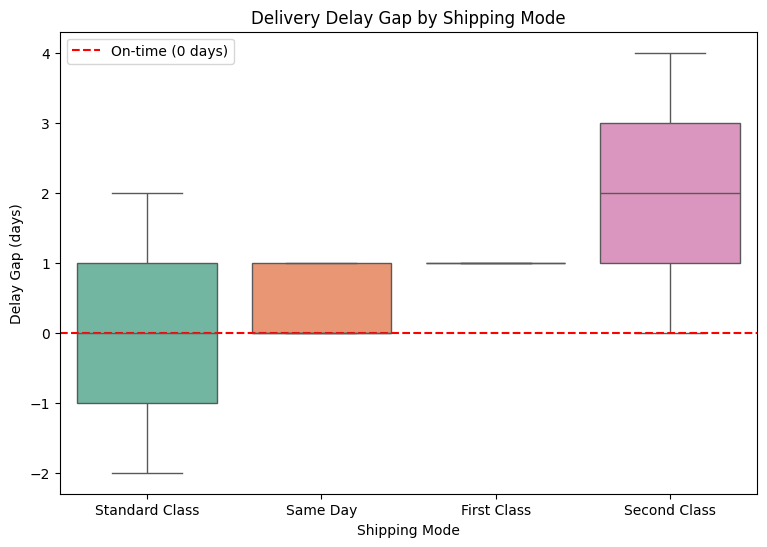

In [4]:
plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Shipping Mode", y="Delay_Gap", palette="Set2")
plt.axhline(0, color='red', linestyle='--', label='On-time (0 days)')
plt.title("Delivery Delay Gap by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Delay Gap (days)")
plt.legend()
plt.show()

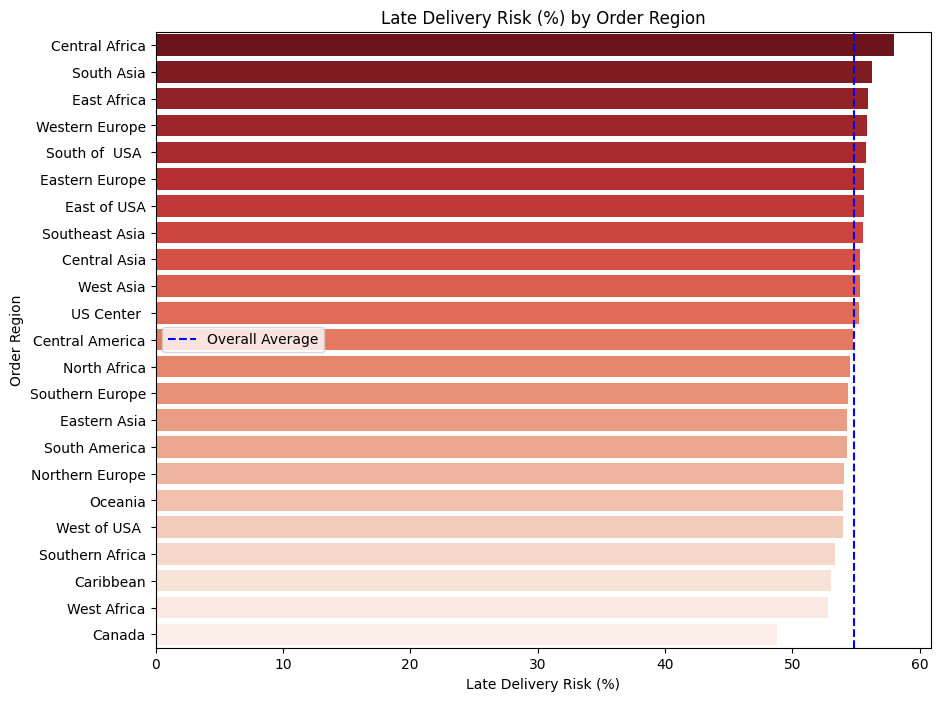

In [6]:
regional_risk = df.groupby("Order Region")["Late_delivery_risk"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,8))
sns.barplot(x=regional_risk.values, y=regional_risk.index, hue=regional_risk.index, palette="Reds_r", legend=False)
plt.axvline(df["Late_delivery_risk"].mean() * 100, color='blue', linestyle='--', label='Overall Average')
plt.title("Late Delivery Risk (%) by Order Region")
plt.xlabel("Late Delivery Risk (%)")
plt.ylabel("Order Region")
plt.legend()
plt.show()

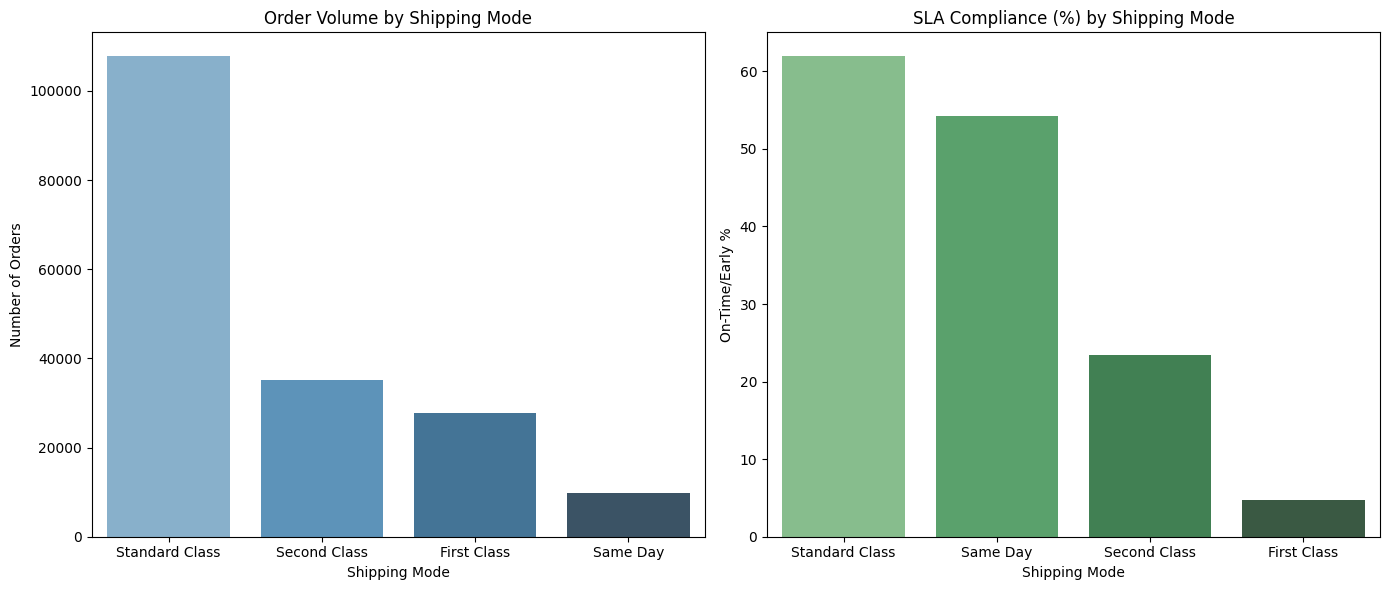

In [7]:
mode_volume = df["Shipping Mode"].value_counts()
mode_compliance = df.groupby("Shipping Mode")["Late_delivery_risk"].apply(lambda x: (x==0).mean()*100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(x=mode_volume.index, y=mode_volume.values, hue=mode_volume.index, 
            palette="Blues_d", legend=False, ax=axes[0])
axes[0].set_title("Order Volume by Shipping Mode")
axes[0].set_ylabel("Number of Orders")
axes[0].set_xlabel("Shipping Mode")

sns.barplot(x=mode_compliance.index, y=mode_compliance.values, hue=mode_compliance.index,
            palette="Greens_d", legend=False, ax=axes[1])
axes[1].set_title("SLA Compliance (%) by Shipping Mode")
axes[1].set_ylabel("On-Time/Early %")
axes[1].set_xlabel("Shipping Mode")

plt.tight_layout()
plt.show()

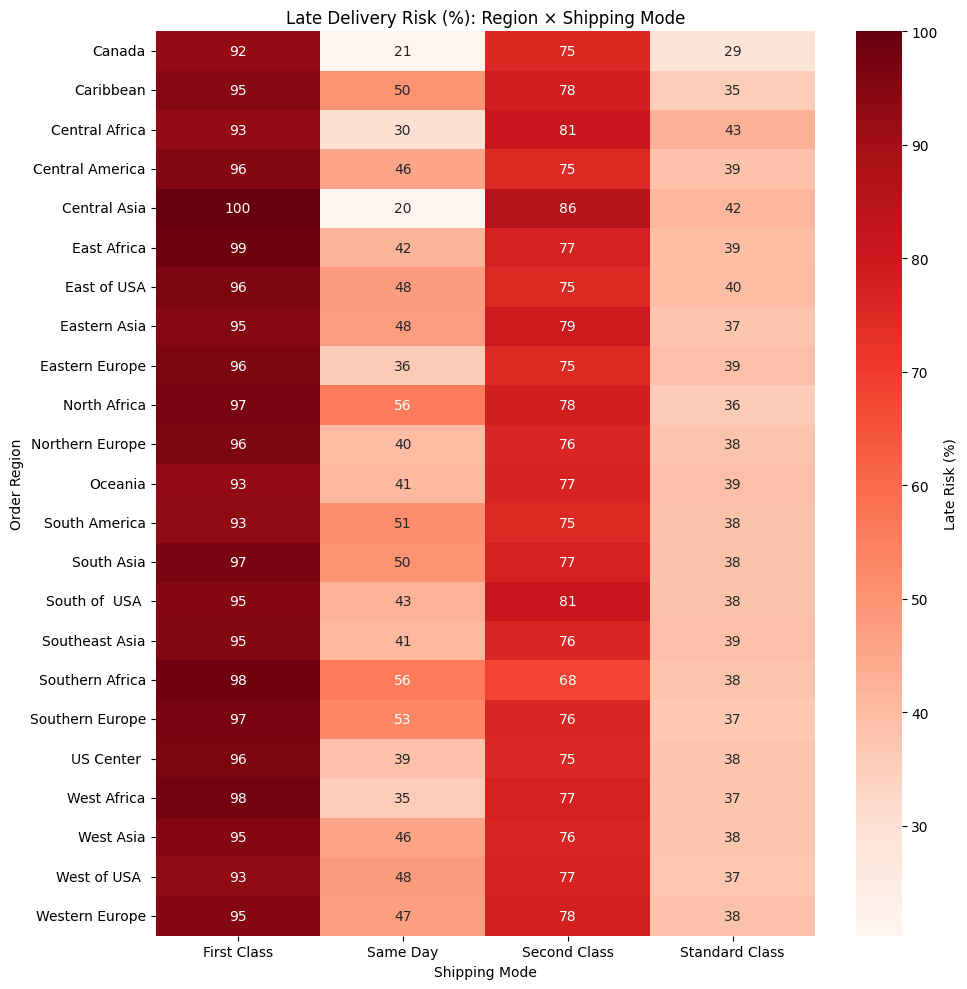

In [8]:
heatmap_data = df.groupby(["Order Region", "Shipping Mode"])["Late_delivery_risk"].mean().unstack() * 100

plt.figure(figsize=(10,10))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="Reds", cbar_kws={'label': 'Late Risk (%)'})
plt.title("Late Delivery Risk (%): Region × Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Order Region")
plt.tight_layout()
plt.show()
